# Evaluation
This notebook serves to showcase how the evaluation pipeline is performed. Full script can be found at `eval.py`

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [52]:
import copy
import numpy as np
import xarray as xr

from causaldynamics.scm import create_scm_graph
from causaldynamics.plot import plot_scm
from causaldynamics.score import score
from causaldynamics.baselines import PCMCIPlus
from causaldynamics.baselines import FPCMCI
from causaldynamics.baselines import DYNOTEARS
from causaldynamics.baselines import VARLiNGAM
from causaldynamics.baselines import NGC_LSTM
from causaldynamics.baselines import TSCI
from causaldynamics.baselines import CUTSPlus
# from causaldynamics.baselines import RCD
# from causaldynamics.baselines import GIN
# from causaldynamics.baselines import GRASP
from causaldynamics.baselines import TCDF

import torch
# DYNOTEARS / FPCMCI + not sure about PCMCIPlus + VARLiNGAM

from tqdm import tqdm
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

In [8]:
from causaldynamics.baselines import PICABU

In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Complete script to generate the dataset can be found under `scripts/generate_<system>.py`. 

Otherwise, follow our instructions to download and process the pre-generated dataset from https://huggingface.co/datasets/kausable/CausalDynamics

In [9]:
# Once you have the dataset, either generated or downloaded
# Notice that the dataset has `time_series` and `adjacency_matrix` variables.
DATA_DIR = Path("../data/simple/noise=0.00_confounder=False/data")  # (you can change this to your own path)
ds = xr.open_dataset(DATA_DIR / "Rossler_N10_T1000.nc")

# Extract timeseries and adjacency matrix as target
timeseries = ds['time_series'].to_numpy().transpose(1, 0, 2) # shape of (N, T, D)
adj_matrix = ds['adjacency_matrix'].to_numpy()

# NOTE: If dataset is from coupled system e.g., "../data/coupled/...", follow these changes to load the data:
## timeseries = ds['time_series'].to_numpy()[..., 0].transpose(1, 0, 2) ## select the first dimension of each multidimensional node
## adj_matrix = ds['adjacency_matrix_summary'].to_numpy() ## `adjacency_matrix_summary` is the true adjacency matrix for coupled system


In [10]:
timeseries.shape

(10, 1000, 3)

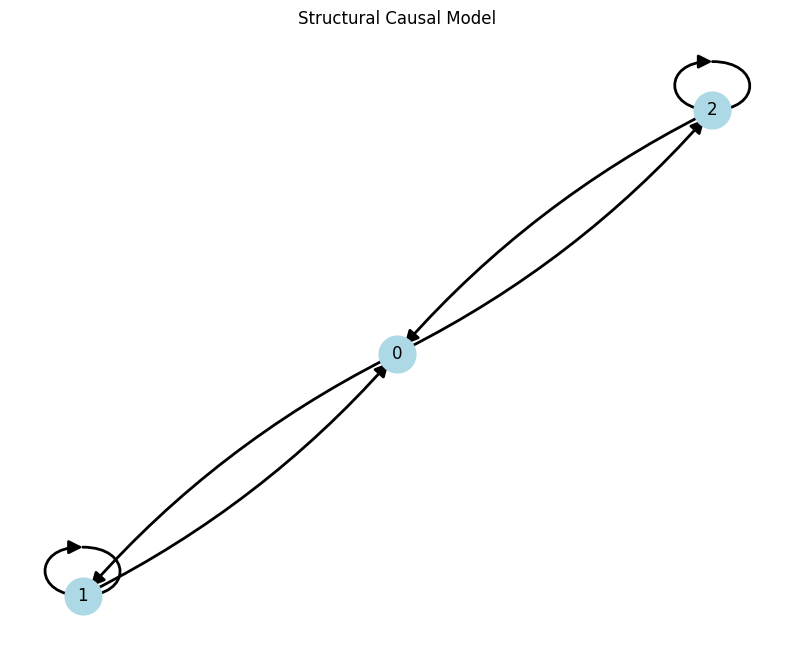

In [11]:
G = create_scm_graph(adj_matrix)
plot_scm(G);


# Evaluation

Evaluate PICABU

In [60]:
tau = 0
T = timeseries.shape[1]
D = timeseries.shape[-1]
sliced_timeseries = np.stack([np.stack([timeseries[k, i:i + tau + 1] for i in range(T - tau)]) for k in range(timeseries.shape[0])])
sliced_timeseries.shape

(10, 1000, 1, 3)

In [61]:
tau_max = 1

## Estimate adjacency matrix
picabu_adj_matrix = []
for x in tqdm(sliced_timeseries):
    picabu_model = PICABU(d_x = x.shape[-1], cuda = True)
    picabu_model.run(X=x)
    picabu_adj_matrix.append(copy.deepcopy(picabu_model.adj_matrix))



  0%|          | 0/10 [00:00<?, ?it/s]

NON LINEAR DYNAMICS
prop of edges 0.993830144405365
prop of edges 0.990668535232544
prop of edges 0.9752901196479797
prop of edges 0.9331867694854736
prop of edges 0.8406241536140442
prop of edges 0.6948533654212952


 10%|█         | 1/10 [00:29<04:25, 29.47s/it]

Number of epochs 6431
Adjacency matrix obtained
NON LINEAR DYNAMICS
prop of edges 0.9937379956245422
prop of edges 0.9901593327522278
prop of edges 0.974156379699707
prop of edges 0.93071049451828
prop of edges 0.8360294699668884
prop of edges 0.6892973780632019


 20%|██        | 2/10 [00:57<03:49, 28.69s/it]

...

 90%|█████████ | 9/10 [04:05<00:27, 27.03s/it]

Number of epochs 5929
Adjacency matrix obtained
NON LINEAR DYNAMICS
prop of edges 0.9933223724365234
prop of edges 0.9878402352333069
prop of edges 0.9670196175575256
prop of edges 0.9132025837898254
prop of edges 0.8049415946006775


100%|██████████| 10/10 [04:32<00:00, 27.21s/it]

Number of epochs 5819
Adjacency matrix obtained


TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

In [68]:
picabu_adj_matrix_all = torch.zeros((10, 3, 3))
for k in range(10):
    picabu_adj_matrix_all[k] = picabu_adj_matrix[k][0]
picabu_adj_matrix_all = picabu_adj_matrix_all.detach().cpu().numpy()

In [69]:
## Compute scores
score(
    preds= np.array(picabu_adj_matrix_all),
    labs= adj_matrix,
    name='PICABU'
)



Scoring...


,PICABU
Metric,
Joint AUROC,0.591667
Individual AUROC,0.591667
Null AUROC,0.500000
Joint AUPRC,0.711889
Individual AUPRC,0.718889
Null AUPRC,0.666667
Joint SHD,36.000000


In [72]:
picabu_adj_matrix_all.shape

(10, 3, 3)

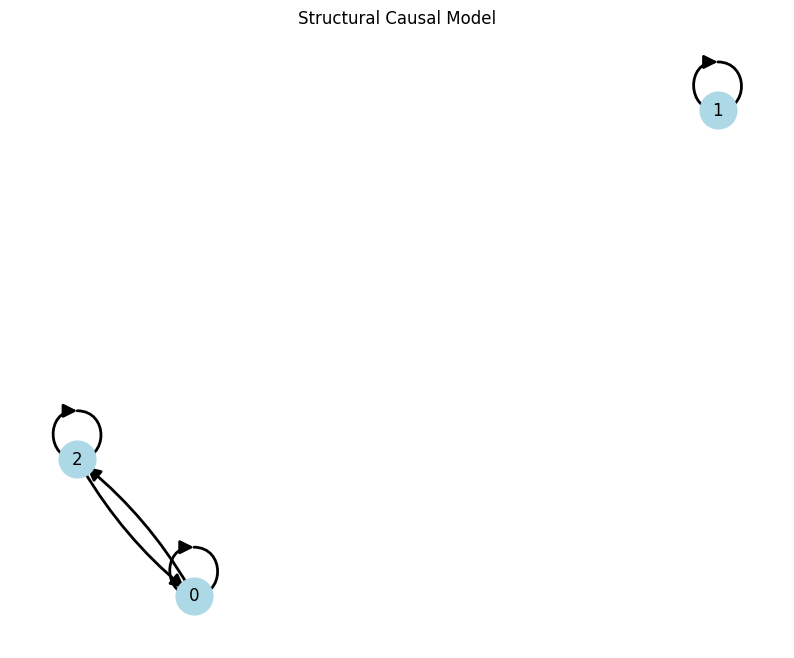

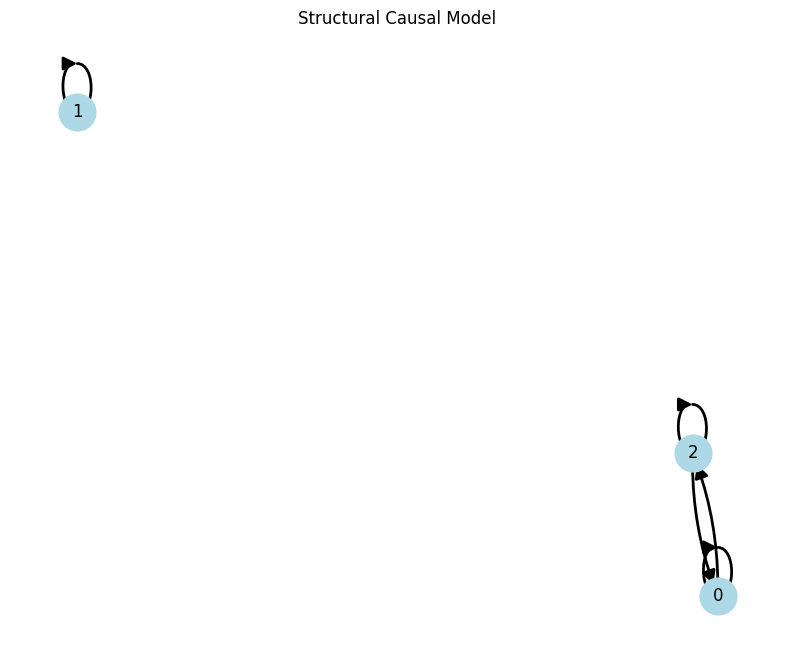

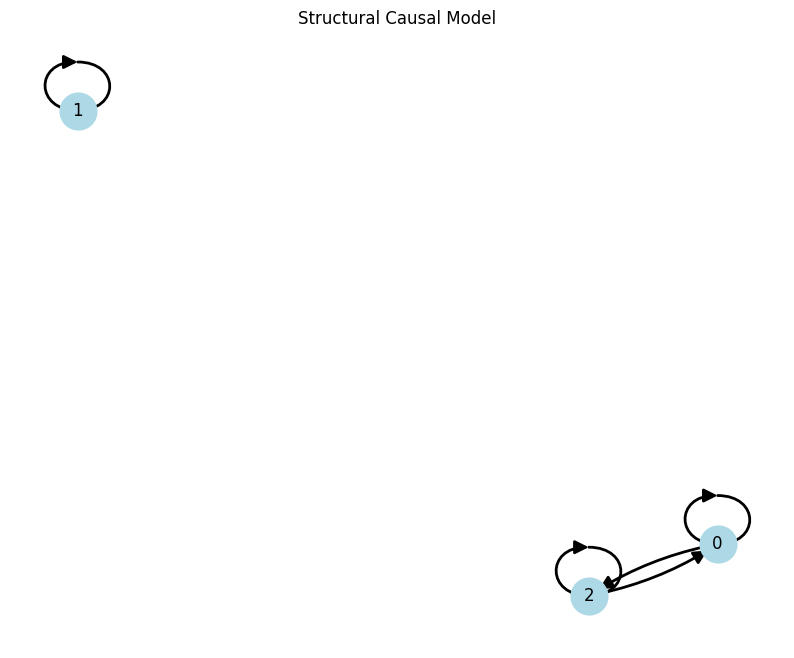

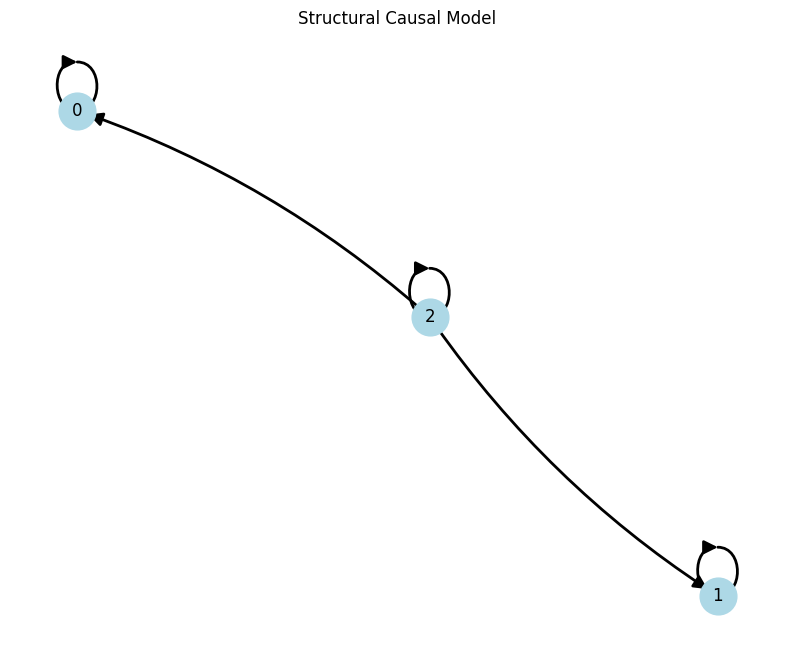

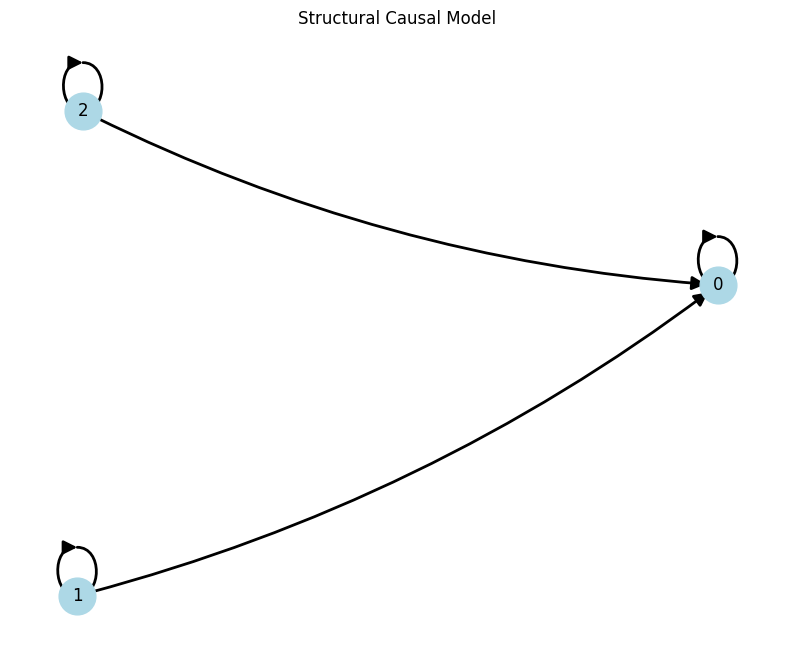

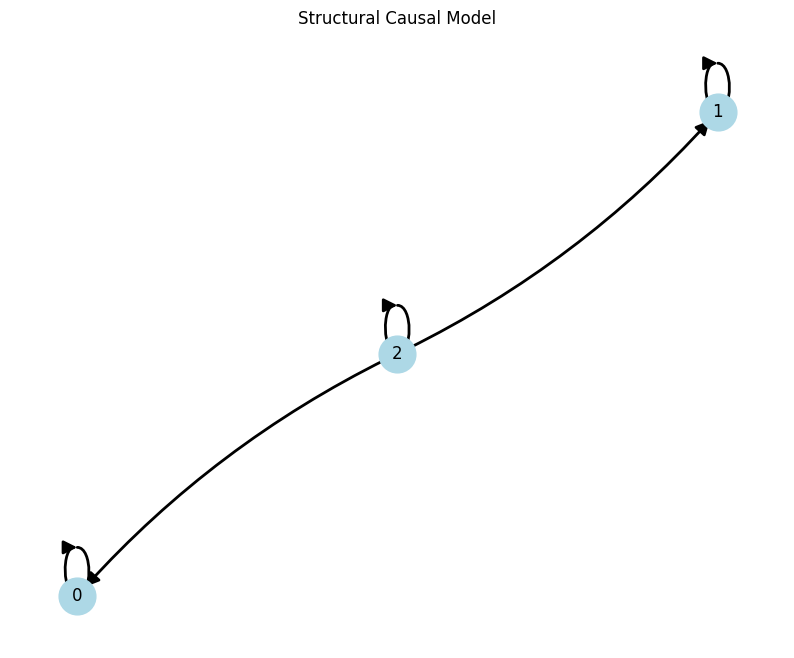

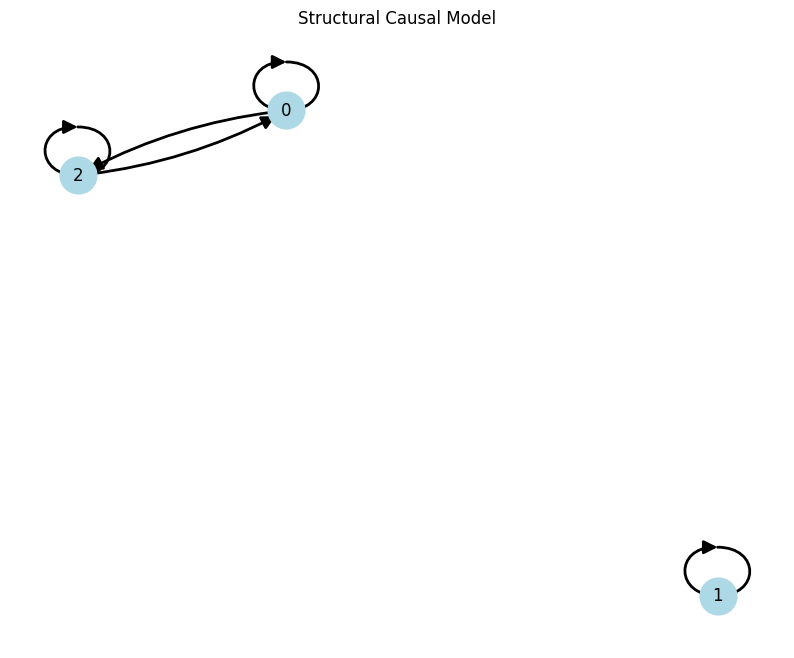

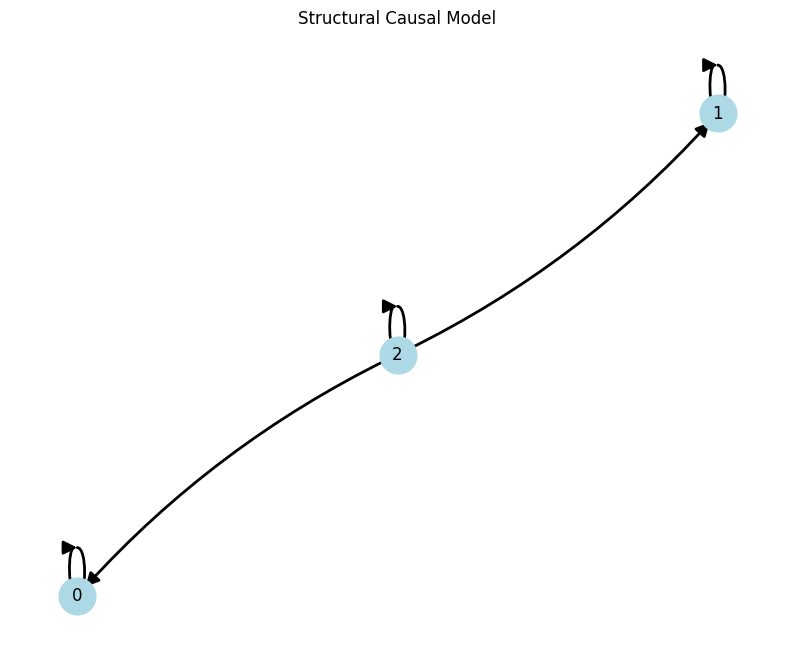

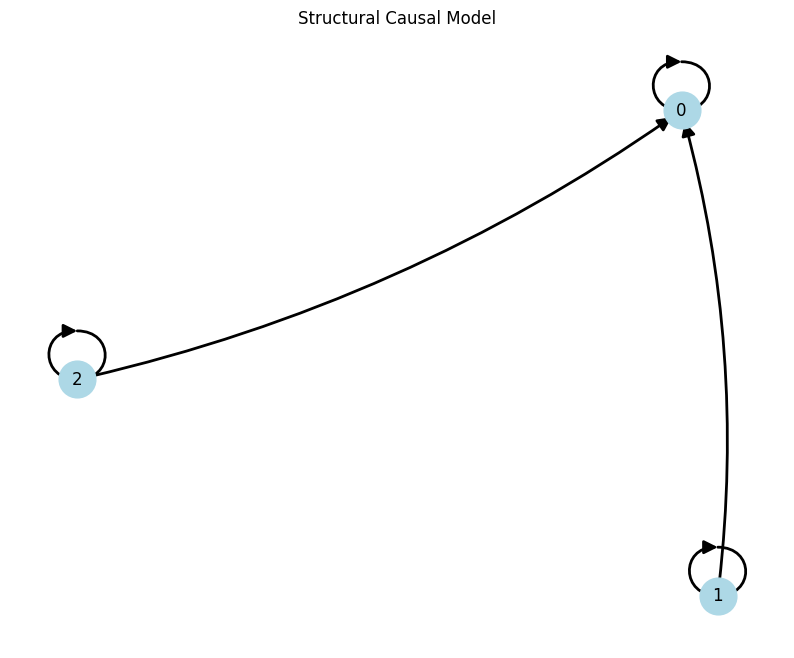

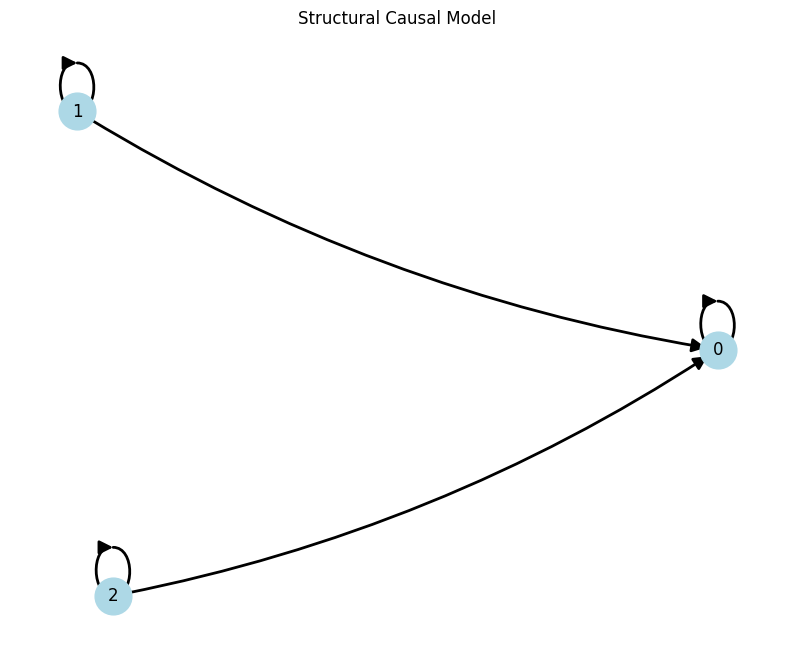

In [73]:
for k in range(10):
    G = create_scm_graph(np.array(picabu_adj_matrix_all)[k])
    plot_scm(G);


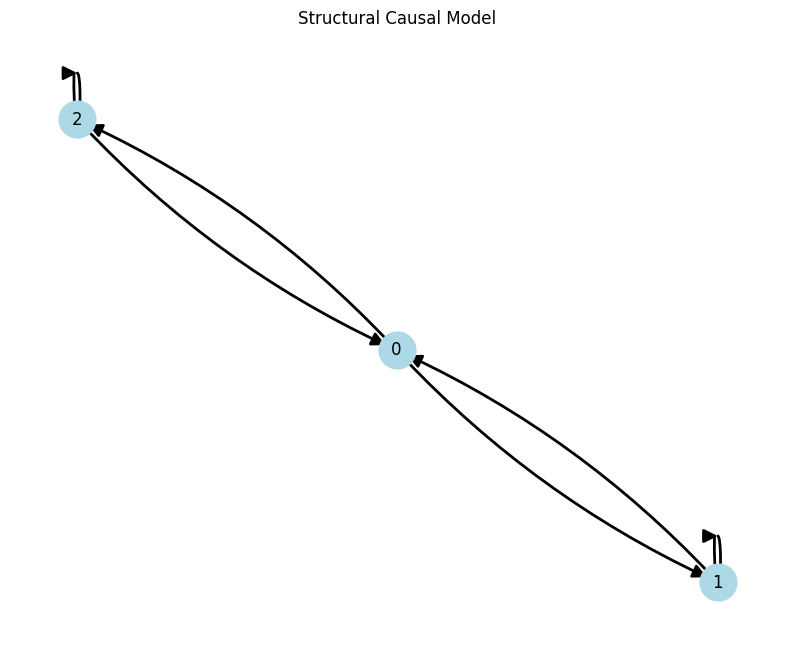

In [32]:
G = create_scm_graph(adj_matrix)
plot_scm(G);


In [29]:
score(
    preds= np.array(picabu_adj_matrix)[0, 0],
    labs= adj_matrix,
    name='PICABU'
)



Scoring...


,PICABU
Metric,
Joint AUROC,0.416667
Individual AUROC,0.416667
Null AUROC,0.500000
Joint AUPRC,0.633333
Individual AUPRC,0.633333
Null AUPRC,0.666667
Joint SHD,5.000000


In [10]:
score(
    preds= np.array(picabu_adj_matrix)[:, 0],
    labs= adj_matrix,
    name='PICABU'
)



Scoring...


,PICABU
Metric,
Joint AUROC,0.541667
Individual AUROC,0.541667
Null AUROC,0.500000
Joint AUPRC,0.686111
Individual AUPRC,0.694444
Null AUPRC,0.666667
Joint SHD,8.000000


Evaluate TCDF

In [56]:
# TCDF
tau_max = 1

## Estimate adjacency matrix
tcdf_adj_matrix = []
for x in tqdm(timeseries):
    tcdf_model = TCDF()
    tcdf_model.run(X=x)
    tcdf_adj_matrix.append(copy.deepcopy(tcdf_model.adj_matrix))

## Compute scores
score(
    preds= np.array(tcdf_adj_matrix),
    labs= adj_matrix,
    name='TCDF'
)


100%|██████████| 10/10 [00:09<00:00,  1.09it/s]

Scoring...


,TCDF
Metric,
Joint AUROC,0.500000
Individual AUROC,0.500000
Null AUROC,0.500000
Joint AUPRC,0.666667
Individual AUPRC,0.666667
Null AUPRC,0.666667
Joint SHD,60.000000


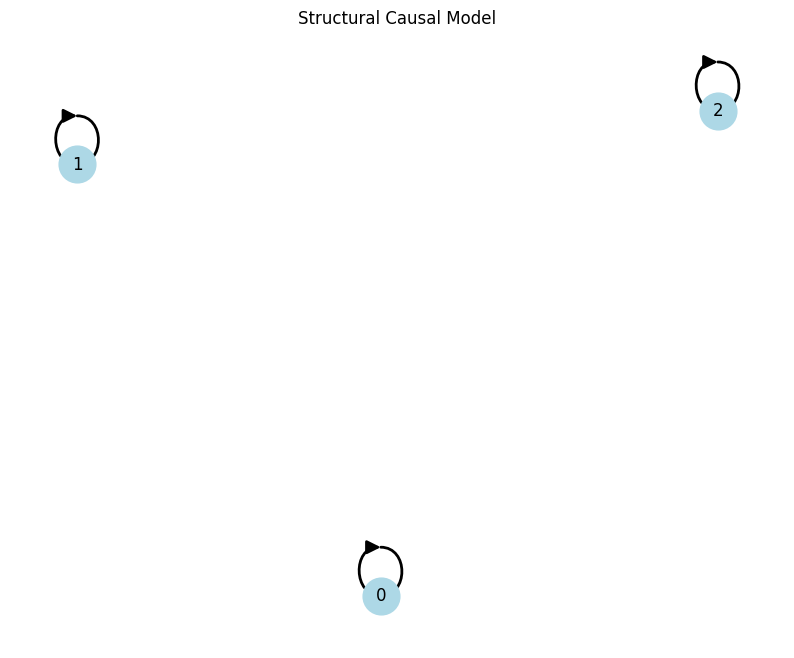

In [5]:
G = create_scm_graph(tcdf_model.adj_matrix)
plot_scm(G);


Evaluate GRASP

In [ ]:
# GRASP
tau_max = 1

## Estimate adjacency matrix
grasp_adj_matrix = []
for x in tqdm(timeseries):
    grasp_model = GRASP(tau_max=tau_max)
    grasp_model.run(X=x)
    grasp_adj_matrix.append(copy.deepcopy(grasp_model.adj_matrix))

## Compute scores
score(
    preds= np.array(grasp_adj_matrix),
    labs= adj_matrix,
    name='GRASP'
)


In [ ]:
G = create_scm_graph(grasp_model.adj_matrix)
plot_scm(G);


Evaluate GIN

In [ ]:
# GIN
tau_max = 1

## Estimate adjacency matrix
gin_adj_matrix = []
for x in tqdm(timeseries):
    gin_model = GIN(tau_max=tau_max)
    gin_model.run(X=x)
    gin_adj_matrix.append(copy.deepcopy(gin_model.adj_matrix))

## Compute scores
score(
    preds= np.array(gin_adj_matrix),
    labs= adj_matrix,
    name='GIN'
)


In [ ]:
G = create_scm_graph(gin_model.adj_matrix)
plot_scm(G);


Evaluate RCD

In [ ]:
# RCD
tau_max = 1

## Estimate adjacency matrix
rcd_adj_matrix = []
for x in tqdm(timeseries):
    rcd_model = RCD(tau_max=tau_max)
    rcd_model.run(X=x)
    rcd_adj_matrix.append(copy.deepcopy(rcd_model.adj_matrix))

## Compute scores
score(
    preds= np.array(rcd_adj_matrix),
    labs= adj_matrix,
    name='RCD'
)


In [ ]:
G = create_scm_graph(rcd_model.adj_matrix)
plot_scm(G);


Evaluate CUTS+

In [ ]:
# CUTS+
tau_max = 1
corr_thres = 0.8

## Estimate adjacency matrix
cuts_adj_matrix = []
for x in tqdm(timeseries):
    cuts_model = CUTSPlus(tau_max=tau_max, corr_thres=corr_thres)
    cuts_model.run(X=x)
    cuts_adj_matrix.append(copy.deepcopy(cuts_model.adj_matrix))

## Compute scores
score(
    preds= np.array(cuts_adj_matrix),
    labs= adj_matrix,
    name='CUTS+'
)


In [ ]:
G = create_scm_graph(cuts_model.adj_matrix)
plot_scm(G);


Evaluate PCMCI+

In [ ]:
# PCMCI+
tau_max = 1
pc_alpha = 0.01

## Estimate adjacency matrix
pcmci_plus_adj_matrix = []
for x in tqdm(timeseries):
    pcmciplus_model = PCMCIPlus(tau_max=tau_max, pc_alpha=pc_alpha)
    pcmciplus_model.run(X=x)
    pcmci_plus_adj_matrix.append(copy.deepcopy(pcmciplus_model.adj_matrix))

## Compute scores
score(
    preds= np.array(pcmci_plus_adj_matrix),
    labs= adj_matrix,
    name='PCMCI+'
)


In [ ]:
G = create_scm_graph(pcmciplus_model.adj_matrix)
plot_scm(G);


Evaluate VARLiNGAM

In [ ]:
# VARLiNGAM
tau_max = 1

## Estimate adjacency matrix
varlingam_adj_matrix = []
for x in tqdm(timeseries):
    varlingam_model = VARLiNGAM(tau_max=tau_max)
    varlingam_model.run(X=x)
    varlingam_adj_matrix.append(copy.deepcopy(varlingam_model.adj_matrix))

## Compute scores
score(
    preds= np.array(varlingam_adj_matrix),
    labs= adj_matrix,
    name='VARLiNGAM'
)


In [ ]:
G = create_scm_graph(varlingam_model.adj_matrix)
plot_scm(G);


Evaluate DYNOTEARS

In [ ]:
# DYNOTEARS
tau_max = 1

## Estimate adjacency matrix
dynotears_adj_matrix = []
for x in tqdm(timeseries):
    dynotears_model = DYNOTEARS(tau_max=tau_max)
    dynotears_model.run(X=x)
    dynotears_adj_matrix.append(copy.deepcopy(dynotears_model.adj_matrix))

## Compute scores
score(
    preds= np.array(dynotears_adj_matrix),
    labs= adj_matrix,
    name='DYNOTEARS'
)


In [ ]:
G = create_scm_graph(dynotears_model.adj_matrix)
plot_scm(G);


Evaluate NeuralGC (cLSTM)

In [ ]:
# cLSTM
tau_max = 1

## Estimate adjacency matrix
clstm_adj_matrix = []
for x in tqdm(timeseries):
    clstm_model = NGC_LSTM(tau_max=tau_max)
    clstm_model.run(X=x)
    clstm_adj_matrix.append(copy.deepcopy(clstm_model.adj_matrix))

## Compute scores
score(
    preds= np.array(clstm_adj_matrix),
    labs= adj_matrix,
    name='cLSTM'
)


In [ ]:
G = create_scm_graph(clstm_model.adj_matrix)
plot_scm(G);
